In [5]:
import numpy as np
import pandas as pd
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [6]:
OUTPUT_DIR = '../../../output/alternative_model/'

# Load model
with open(OUTPUT_DIR + 'best_model_xgboost.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open(OUTPUT_DIR + 'feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

with open(OUTPUT_DIR + 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load splits
X_train = pd.read_csv(OUTPUT_DIR + 'X_train.csv')
X_val   = pd.read_csv(OUTPUT_DIR + 'X_val.csv')
X_test  = pd.read_csv(OUTPUT_DIR + 'X_test.csv')
y_train = pd.read_csv(OUTPUT_DIR + 'y_train.csv').squeeze()
y_val   = pd.read_csv(OUTPUT_DIR + 'y_val.csv').squeeze()
y_test  = pd.read_csv(OUTPUT_DIR + 'y_test.csv').squeeze()

print(f'Model loaded: {type(xgb_model).__name__}')
print(f'Features: {len(feature_cols)}')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Default rate - Train: {y_train.mean():.3f}, Val: {y_val.mean():.3f}, Test: {y_test.mean():.3f}')

Model loaded: XGBClassifier
Features: 25
Train: (7000, 21), Val: (1500, 21), Test: (1500, 21)
Default rate - Train: 0.358, Val: 0.358, Test: 0.357


In [7]:
def evaluate_model(name, model, X, y, threshold=0.5, verbose=True):
    """Evaluate model at given threshold. Returns metrics dict."""
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)
    
    metrics = {
        'AUC':       round(roc_auc_score(y, proba), 4),
        'F1':        round(f1_score(y, preds), 4),
        'Precision': round(precision_score(y, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y, preds), 4),
        'Threshold': threshold,
    }
    
    if verbose:
        print(f'\n[{name}] @ threshold={threshold:.3f}')
        print(f'  AUC={metrics["AUC"]:.4f}  F1={metrics["F1"]:.4f}  '
              f'Precision={metrics["Precision"]:.4f}  Recall={metrics["Recall"]:.4f}')
    
    return metrics

print('Evaluate function defined ✓')

Evaluate function defined ✓


In [8]:
# ── Add 4 missing engineered features ──────────────────────────────────────

def add_engineered_features(df):
    df = df.copy()
    df['financial_stress_index'] = df['debt_ratio'] * df['behavior_volatility']
    df['academic_resilience']    = df['gpa_latest'] * df['support_numeric']
    df['risk_compounding']       = (df['severe_behavior_flag'] 
                                    + df['thin_support_flag'] 
                                    + df['high_pressure_flag'])
    df['loan_to_maturity_ratio'] = df['loan_amount'] / (df['maturity_score'] + 0.1)
    return df

X_train = add_engineered_features(X_train)
X_val   = add_engineered_features(X_val)
X_test  = add_engineered_features(X_test)

print('Features added:', ['financial_stress_index','academic_resilience',
                          'risk_compounding','loan_to_maturity_ratio'])
print(f'X_val shape now: {X_val.shape}')  # should be (n, 25)

Features added: ['financial_stress_index', 'academic_resilience', 'risk_compounding', 'loan_to_maturity_ratio']
X_val shape now: (1500, 25)


In [9]:
print('=== BASELINE (threshold=0.5) ===')
baseline_val  = evaluate_model('Baseline XGBoost [Val]',  xgb_model, X_val,  y_val,  threshold=0.5)
baseline_test = evaluate_model('Baseline XGBoost [Test]', xgb_model, X_test, y_test, threshold=0.5)

print('\n--- Targets ---')
print('AUC ≥ 0.75 | Precision ≥ 0.55 | F1 ≥ 0.62')

=== BASELINE (threshold=0.5) ===

[Baseline XGBoost [Val]] @ threshold=0.500
  AUC=0.7091  F1=0.5884  Precision=0.5124  Recall=0.6909

[Baseline XGBoost [Test]] @ threshold=0.500
  AUC=0.7184  F1=0.5712  Precision=0.4959  Recall=0.6735

--- Targets ---
AUC ≥ 0.75 | Precision ≥ 0.55 | F1 ≥ 0.62


In [10]:
val_proba = xgb_model.predict_proba(X_val)[:, 1]

# Compute P-R curve on validation set
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_val, val_proba)

# F1 at each threshold
f1_arr = 2 * (precision_arr[:-1] * recall_arr[:-1]) / (precision_arr[:-1] + recall_arr[:-1] + 1e-8)

# Also compute F-beta (beta=0.5 → favor precision over recall for credit)
beta = 0.5
fbeta_arr = (1 + beta**2) * (precision_arr[:-1] * recall_arr[:-1]) / \
            (beta**2 * precision_arr[:-1] + recall_arr[:-1] + 1e-8)

best_f1_idx    = f1_arr.argmax()
best_fbeta_idx = fbeta_arr.argmax()

best_threshold_f1    = thresholds_arr[best_f1_idx]
best_threshold_fbeta = thresholds_arr[best_fbeta_idx]

print(f'Best threshold (F1 max):         {best_threshold_f1:.4f}  →  F1={f1_arr[best_f1_idx]:.4f}')
print(f'Best threshold (F0.5 max):       {best_threshold_fbeta:.4f}  →  F0.5={fbeta_arr[best_fbeta_idx]:.4f}')

Best threshold (F1 max):         0.3694  →  F1=0.6031
Best threshold (F0.5 max):       0.5880  →  F0.5=0.5518


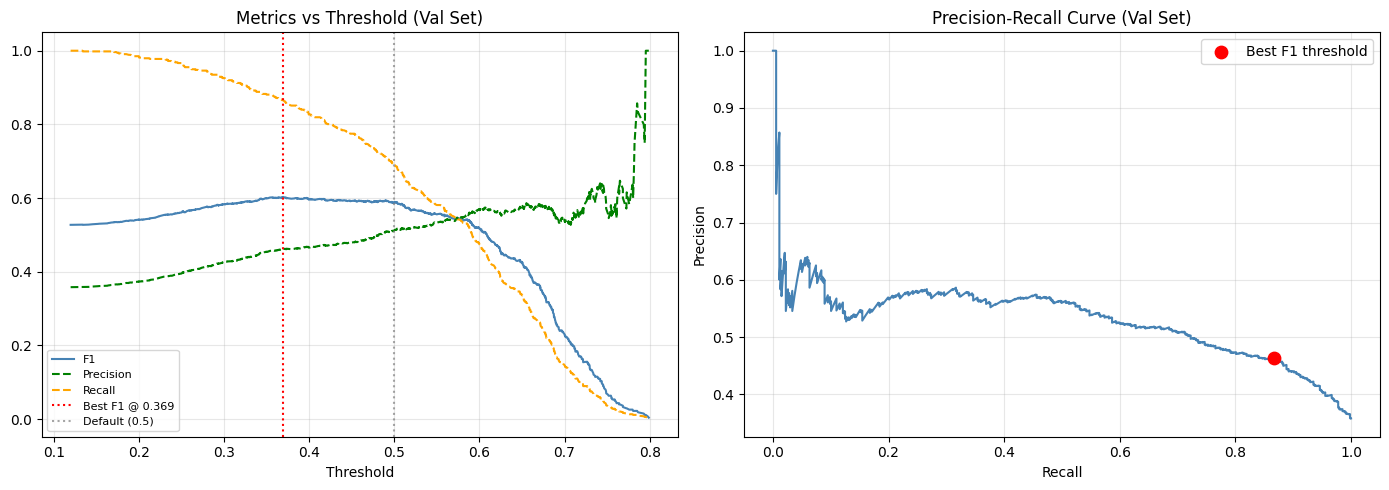

Chart saved ✓


In [11]:
# Plot F1 / Precision / Recall vs Threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: F1 curve
ax = axes[0]
ax.plot(thresholds_arr, f1_arr, label='F1', color='steelblue')
ax.plot(thresholds_arr, precision_arr[:-1], label='Precision', color='green', linestyle='--')
ax.plot(thresholds_arr, recall_arr[:-1], label='Recall', color='orange', linestyle='--')
ax.axvline(best_threshold_f1, color='red', linestyle=':', label=f'Best F1 @ {best_threshold_f1:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default (0.5)')
ax.set_xlabel('Threshold')
ax.set_title('Metrics vs Threshold (Val Set)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: Precision-Recall curve
ax = axes[1]
ax.plot(recall_arr, precision_arr, color='steelblue')
ax.scatter(recall_arr[best_f1_idx], precision_arr[best_f1_idx],
           color='red', zorder=5, s=80, label=f'Best F1 threshold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (Val Set)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [12]:
# Compare 3 thresholds on TEST set
print('=== THRESHOLD COMPARISON ON TEST SET ===')
results = []
for name, thr in [
    ('Baseline (0.5)',            0.5),
    (f'Best F1 ({best_threshold_f1:.3f})',    best_threshold_f1),
    (f'Best F0.5 ({best_threshold_fbeta:.3f})', best_threshold_fbeta),
]:
    m = evaluate_model(name, xgb_model, X_test, y_test, threshold=thr)
    m['Model'] = name
    results.append(m)

results_df = pd.DataFrame(results).set_index('Model')[['AUC', 'Precision', 'Recall', 'F1', 'Threshold']]
print('\n', results_df.to_string())

=== THRESHOLD COMPARISON ON TEST SET ===

[Baseline (0.5)] @ threshold=0.500
  AUC=0.7184  F1=0.5712  Precision=0.4959  Recall=0.6735

[Best F1 (0.369)] @ threshold=0.369
  AUC=0.7184  F1=0.5977  Precision=0.4574  Recall=0.8619

[Best F0.5 (0.588)] @ threshold=0.588
  AUC=0.7184  F1=0.5406  Precision=0.5691  Recall=0.5149

                      AUC  Precision  Recall     F1  Threshold
Model                                                        
Baseline (0.5)    0.7184     0.4959  0.6735 0.5712     0.5000
Best F1 (0.369)   0.7184     0.4574  0.8619 0.5977     0.3694
Best F0.5 (0.588) 0.7184     0.5691  0.5149 0.5406     0.5880


In [13]:
try:
    from imblearn.over_sampling import SMOTE
    print('imbalanced-learn installed ✓')
except ImportError:
    print('Installing imbalanced-learn...')
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE
    print('imbalanced-learn installed ✓')

Installing imbalanced-learn...
imbalanced-learn installed ✓


In [14]:
import xgboost as xgb

# Apply SMOTE
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After  SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}')
print(f'Train size after SMOTE: {len(X_train_sm)}')

Before SMOTE: {0: 4495, 1: 2505}
After  SMOTE: {1: 4495, 0: 4495}
Train size after SMOTE: 8990


In [15]:
# Retrain XGBoost on balanced data (no scale_pos_weight needed)
xgb_params = {
    'max_depth': 4,
    'learning_rate': 0.03,
    'n_estimators': 500,
    'min_child_weight': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.1,
    'reg_alpha': 0.5,
    'reg_lambda': 1.5,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': 42,
    'use_label_encoder': False,
    'early_stopping_rounds': 50,
}

xgb_smote = xgb.XGBClassifier(**xgb_params)
xgb_smote.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    verbose=50
)
print('\nSMOTE model training complete ✓')

[0]	validation_0-auc:0.68856
[50]	validation_0-auc:0.70411
[100]	validation_0-auc:0.70778
[150]	validation_0-auc:0.70787
[177]	validation_0-auc:0.70817

SMOTE model training complete ✓


In [16]:
# Find best threshold for SMOTE model
smote_val_proba = xgb_smote.predict_proba(X_val)[:, 1]
prec_s, rec_s, thr_s = precision_recall_curve(y_val, smote_val_proba)
f1_s = 2 * (prec_s[:-1] * rec_s[:-1]) / (prec_s[:-1] + rec_s[:-1] + 1e-8)
best_thr_smote = thr_s[f1_s.argmax()]

print(f'SMOTE best threshold: {best_thr_smote:.4f}')

SMOTE best threshold: 0.3623


In [17]:
print('=' * 65)
print('FINAL COMPARISON ON TEST SET')
print('=' * 65)

final_results = []
configs = [
    ('Baseline XGBoost (0.5)',                  xgb_model,   0.5),
    (f'XGBoost + Opt. Threshold ({best_threshold_f1:.3f})', xgb_model,   best_threshold_f1),
    ('XGBoost + SMOTE (0.5)',                   xgb_smote,   0.5),
    (f'XGBoost + SMOTE + Opt. Threshold ({best_thr_smote:.3f})', xgb_smote, best_thr_smote),
]

for name, model, thr in configs:
    m = evaluate_model(name, model, X_test, y_test, threshold=thr)
    m['Model'] = name
    final_results.append(m)

final_df = pd.DataFrame(final_results).set_index('Model')[['AUC', 'Precision', 'Recall', 'F1']]
print('\n', final_df.to_string())

print('\n--- Targets ---')
print('AUC ≥ 0.75 | Precision ≥ 0.55 | F1 ≥ 0.62')

FINAL COMPARISON ON TEST SET

[Baseline XGBoost (0.5)] @ threshold=0.500
  AUC=0.7184  F1=0.5712  Precision=0.4959  Recall=0.6735

[XGBoost + Opt. Threshold (0.369)] @ threshold=0.369
  AUC=0.7184  F1=0.5977  Precision=0.4574  Recall=0.8619

[XGBoost + SMOTE (0.5)] @ threshold=0.500
  AUC=0.7182  F1=0.5448  Precision=0.5626  Recall=0.5280

[XGBoost + SMOTE + Opt. Threshold (0.362)] @ threshold=0.362
  AUC=0.7182  F1=0.6021  Precision=0.4826  Recall=0.8004

                                             AUC  Precision  Recall     F1
Model                                                                    
Baseline XGBoost (0.5)                   0.7184     0.4959  0.6735 0.5712
XGBoost + Opt. Threshold (0.369)         0.7184     0.4574  0.8619 0.5977
XGBoost + SMOTE (0.5)                    0.7182     0.5626  0.5280 0.5448
XGBoost + SMOTE + Opt. Threshold (0.362) 0.7182     0.4826  0.8004 0.6021

--- Targets ---
AUC ≥ 0.75 | Precision ≥ 0.55 | F1 ≥ 0.62


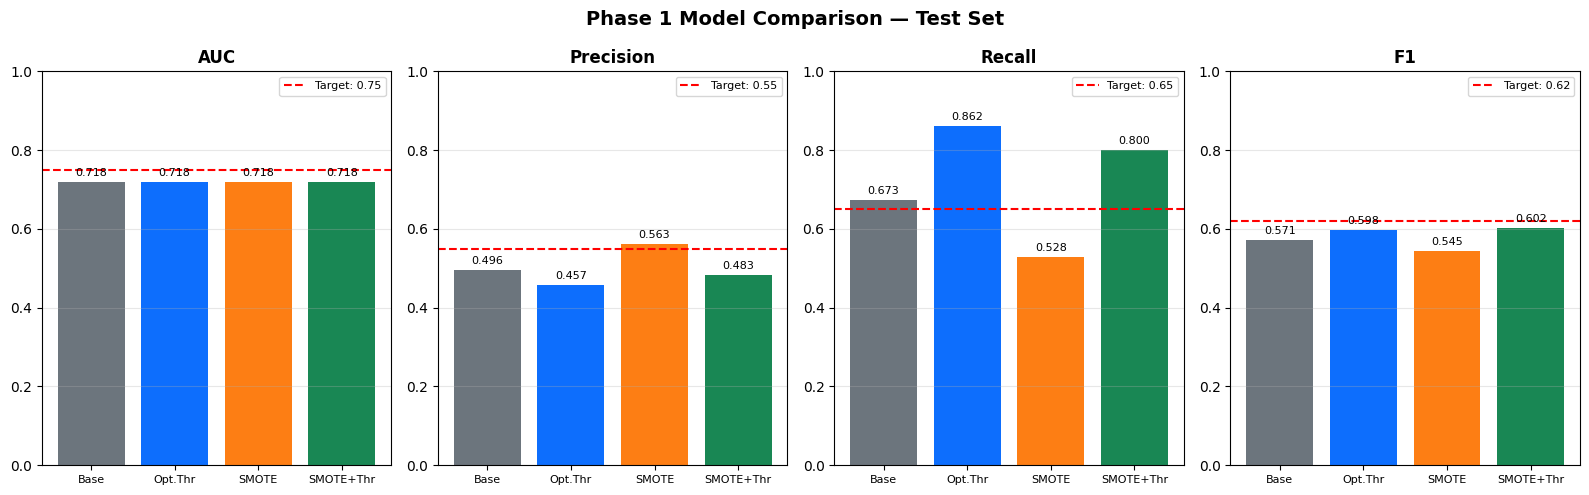

Chart saved ✓


In [18]:
# Visual comparison
metrics_to_plot = ['AUC', 'Precision', 'Recall', 'F1']
targets = {'AUC': 0.75, 'Precision': 0.55, 'Recall': 0.65, 'F1': 0.62}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#6c757d', '#0d6efd', '#fd7e14', '#198754']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    vals = [r[metric] for r in final_results]
    bars = ax.bar(range(len(configs)), vals, color=colors)
    ax.axhline(targets[metric], color='red', linestyle='--', linewidth=1.5, label=f'Target: {targets[metric]}')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels(['Base', 'Opt.Thr', 'SMOTE', 'SMOTE+Thr'], fontsize=8)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    # Value labels
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Phase 1 Model Comparison — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'phase1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [19]:
# Pick best model based on F1 score
best_result = max(final_results, key=lambda x: x['F1'])
print(f'Best model: {best_result["Model"]}')
print(f'  AUC={best_result["AUC"]:.4f}, Precision={best_result["Precision"]:.4f}, '
      f'Recall={best_result["Recall"]:.4f}, F1={best_result["F1"]:.4f}')

# Determine which model to save
is_smote = 'SMOTE' in best_result['Model']
best_model_obj = xgb_smote if is_smote else xgb_model
best_threshold = best_result['Threshold']

# Save
with open(OUTPUT_DIR + 'best_model_phase1.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

# Save threshold as well
with open(OUTPUT_DIR + 'best_threshold_phase1.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

print(f'\nModel saved → output/alternative_model/best_model_phase1.pkl')
print(f'Threshold saved → output/alternative_model/best_threshold_phase1.pkl  (value={best_threshold:.4f})')

# Summary report
print('\n' + '='*65)
print('PHASE 1 SUMMARY')
print('='*65)
print(f'  Baseline AUC:   {baseline_test["AUC"]:.4f}  →  Phase1 AUC:   {best_result["AUC"]:.4f}')
print(f'  Baseline Prec:  {baseline_test["Precision"]:.4f}  →  Phase1 Prec:  {best_result["Precision"]:.4f}')
print(f'  Baseline F1:    {baseline_test["F1"]:.4f}  →  Phase1 F1:    {best_result["F1"]:.4f}')
print(f'  Used SMOTE: {is_smote}, Best threshold: {best_threshold:.4f}')

Best model: XGBoost + SMOTE + Opt. Threshold (0.362)
  AUC=0.7182, Precision=0.4826, Recall=0.8004, F1=0.6021

Model saved → output/alternative_model/best_model_phase1.pkl
Threshold saved → output/alternative_model/best_threshold_phase1.pkl  (value=0.3623)

PHASE 1 SUMMARY
  Baseline AUC:   0.7184  →  Phase1 AUC:   0.7182
  Baseline Prec:  0.4959  →  Phase1 Prec:  0.4826
  Baseline F1:    0.5712  →  Phase1 F1:    0.6021
  Used SMOTE: True, Best threshold: 0.3623
